# Tarea 0 --- IELE756

**Team members**: Catalina Cornejo, Javiera García  

**Comunas**: Renca, Lo Barnechea, Buin

**Date**: 15/03/2026

## Part 1: Census 2024 

Import the pandas library and check that the environment is working correctly. The pandas version is printed to confirm that the library is available.

In [1]:
import pandas as pd

print("Hello, IELE756!")
print(f"pandas version: {pd.__version__}")

Hello, IELE756!
pandas version: 3.0.1


### 1.1 Load

* Import the pandas library again. 
* Load the Census 2024 persona table using `pandas.read_parquet`. Since the dataset contains millions of rows and many variables, only a subset of relevant columns is selected to reduce memory usage.

In [2]:
import pandas as pd
persona = pd.read_parquet(
    "personas_censo2024.parquet",
    columns=[
        "region",
        "comuna",
        "sexo",
        "edad",
        "p27_nacionalidad",
        "p27_nacionalidad_rec",
        "escolaridad",
        "sit_fuerza_trabajo"
    ]
)

### 1.2 Inspect

Dataset dimensions. Shows how many rows (observations) and columns (variables) are included in the dataset.

In [4]:
persona.shape

(18480432, 8)

Variable data types. Examines how each column is stored in the dataset (for example integers or objects).

In [5]:
persona.dtypes

region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

Show the first 10 rows of the dataset to inspect its structure

In [6]:
persona.head(10)

,region,comuna,sexo,edad,p27_nacionalidad,p27_nacionalidad_rec,escolaridad,sit_fuerza_trabajo
0,5,5802,2,80,1,1,17,3.0
1,5,5802,1,52,1,1,14,1.0
2,5,5802,2,45,1,1,12,1.0
3,5,5802,2,8,1,1,2,NaN
4,4,4303,1,69,1,1,12,3.0
5,4,4303,2,65,1,1,12,3.0
6,4,4303,1,58,1,1,15,1.0
7,11,11202,2,-66,-66,1,8,1.0
8,11,11202,1,-66,-66,1,5,1.0
9,11,11202,1,-66,-66,1,3,NaN


Dataset summary. Number of entries, the data types of each column, and whether there are missing values (nulls). 

In [7]:
persona.info()

<class 'pandas.DataFrame'>
RangeIndex: 18480432 entries, 0 to 18480431
Data columns (total 8 columns):
 #   Column                Dtype  
---  ------                -----  
 0   region                int32  
 1   comuna                int32  
 2   sexo                  int32  
 3   edad                  int32  
 4   p27_nacionalidad      int32  
 5   p27_nacionalidad_rec  int32  
 6   escolaridad           int32  
 7   sit_fuerza_trabajo    float64
dtypes: float64(1), int32(7)
memory usage: 634.5 MB


### 1.3 Filter to region

Filter the dataset to a region. In the Census dataset, the variable "region" is represented by a numeric code. The selected region is the Tarapacá Region, region number 1.
* Count the number of observations that belong to the selected region. 

In [52]:
my_region = persona[persona["region"] == 1]
print(f"Rows in my region: {len(my_region):,}")

Rows in my region: 369,806


### 1.4 First look at nationality

Nationality distribution. 
* The distribution of the variable `p27_nacionalidad_rec` is examined for the selected region using `value_counts()`. This function counts how many observations belong to each nationality category in the dataset.
* The relative frequency of each category is calculated using `value_counts(normalize=True)`. This expresses the counts as proportions instead of absolute numbers.
* The percentage of individuals classified as "Extranjero" is extracted in order to estimate the share of foreign-born residents in the region.
* The variable `p27_nacionalidad_rec` records nationality using numeric codes. 
According to the Census documentation, the categories are:
1 = Has Chilean nationality, 2 = Does not have Chilean nationality, -99 = missing or suppressed responses.
* The value 2 corresponds to foreign-born individuals in the variable `p27_nacionalidad_rec`. The expression `foreign.get(2, 0)` retrieves the proportion associated with the value 2. If this value is not present in the data, the function returns 0 instead of producing an error. The format specification `:.1%` converts the number into a percentage and displays it with one decimal place.


In [56]:
foreign = my_region["p27_nacionalidad_rec"].value_counts()
print(foreign)

p27_nacionalidad_rec
 1     286268
 2      80574
-99      2964
Name: count, dtype: int64


In [53]:
foreign = my_region["p27_nacionalidad_rec"] \
    .value_counts(normalize=True)
print(f"% foreign-born: {foreign.get(2, 0):.1%}")

% foreign-born: 21.8%


## Part 2: ENO — Notifiable Diseases 

### 2.1 Load

Loading the ENO dataset. The dataset is loaded using `pandas.read_csv()`. Since the file is semicolon-delimited, the argument `sep=";"` is specified. The encoding `utf-8-sig` is used to correctly read special characters. After loading the dataset, the total number of rows and the list of column names are displayed in order to understand the size and structure of the dataset.

In [4]:
eno = pd.read_csv(
   "20241218_base_eno_final.csv",
    sep=";", encoding="utf-8-sig")
print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())


/var/folders/47/ynq4knz96xj116vxld4dytjr0000gn/T/ipykernel_32849/2215609089.py:1: DtypeWarning: Columns (0: Autóctono, 1: presenta_sintomas, 2: sintomas, 3: consumo_agua_no_potable, 4: antecedente_teniasis, 5: imagenologia, 6: manifestaciones, 7: existe_coinfeccion, 8: via_transmision, 9: n_parejas_sexuales, 10: uso_preservativo, 11: paciente_inmunosuprimido, 12: vih, 13: pareja, 14: exantema_mpox, 15: factores_exposicion, 16: neumonia, 17: contacto_aves, 18: genotipo_1, 19: recuento_linfocitos, 20: clasificacion_final_vih, 21: etapa_vih_sida, 22: hospitalizacion, 23: nombre_primer_sintoma, 24: SeroGrupo) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv(


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


### 2.2 Filter to region

Filtering the ENO dataset by region. In the ENO dataset, the variable region is stored as text. This step creates a subset of the ENO dataset that contains only the observations for the selected region and print the number of rows corresponding to the selected region (Región de Tarapacá). 

In [6]:
eno_region = eno[eno["region"] == "Región de Tarapacá"]
print(f"Rows in my region: {len(eno_region):,}")

Rows in my region: 13,778


### 2.3 Notifications by year

The number of disease notifications is examined by year using the variable `anho_notificacion`. 
The function `value_counts()` counts the number of notifications in each year. The results are then sorted by year using `sort_index()` to display the years in chronological order.

In [7]:
eno_region["anho_notificacion"].value_counts().sort_index() 

anho_notificacion
2007     447
2008     634
2009     649
2010     637
2011     672
2012     987
2013     691
2014     594
2015     686
2016     791
2017     823
2018    1407
2019    1018
2020     567
2021     807
2022     895
2023     885
2024     588
Name: count, dtype: int64

The results are visualized using a bar chart. A bar chart is then created using `.plot(kind="bar")` to visualize how the number of notifications changes over time. The `xlabel`, `ylabel`, and `title` arguments are used to label the axes and provide a descriptive title for the chart.

<Axes: title={'center': 'ENO Notifications by Year'}, xlabel='Year', ylabel='Number of notifications'>

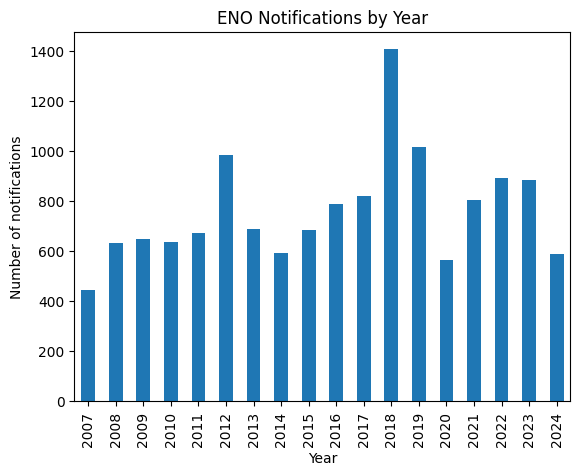

In [13]:
notifications_by_year = eno_region["anho_notificacion"].value_counts().sort_index()
notifications_by_year.plot(kind="bar", xlabel="Year", ylabel="Number of notifications", title="ENO Notifications by Year")

### 2.4 Top 5 diseases

The most frequently notified diseases in the selected region are identified using the variable `ENO`, which contains the disease name. 

The function `value_counts()` counts the number of notifications for each disease, and `head(5)` selects the five most frequent ones. The results are then visualized using a horizontal bar chart.

In [14]:
eno_region["ENO"].value_counts().head(5)

ENO
Sifilis                 4127
Infección gonocócica    1967
VIH                     1837
Hepatitis A             1727
Parotiditis             1611
Name: count, dtype: int64

The results are stored in `top_diseases` and visualized using a horizontal bar chart (`kind="barh"`). The labels and title are added using `matplotlib`.

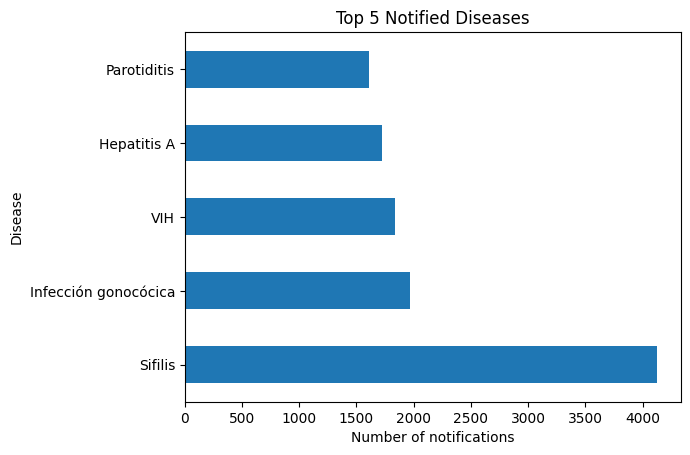

In [18]:
import matplotlib.pyplot as plt
top_diseases = eno_region["ENO"].value_counts().head(5)
top_diseases.plot(kind="barh")

plt.xlabel("Number of notifications")
plt.ylabel("Disease")
plt.title("Top 5 Notified Diseases")

plt.show()

### 2.5 Nationality distribution

The distribution of the variable `nacionalidad` is examined for the selected region using `value_counts()`. 
`Normalize=True`: When this argument is set to True, value_counts() calculates the relative frequencies of each unique value, meaning it returns the proportion of each nationality instead of the raw counts.
`.map('{:.2%}'.format)`: This part applies a formatting string to each proportion.
`'{:.2%}'` is a format specifier that takes a float, multiplies it by 100, and formats it as a percentage with two decimal places.
This format is used to apply string to each numerical value generated by value_counts(normalize=True).
In essence, this line of code calculates the proportion of each nationality in the eno_region dataset and then displays these proportions as formatted percentages.

It is expected that a category such as "Desconocido" (unknown) may appear in the data. This category is reported as part of the results and is not removed from the analysis.

In [55]:
eno_region["nacionalidad"].value_counts()

nacionalidad
Desconocido    6235
Chile          4197
Extranjero     3346
Name: count, dtype: int64

In [54]:
eno_region["nacionalidad"].value_counts(normalize=True).map('{:.2%}'.format)

nacionalidad
Desconocido    45.25%
Chile          30.46%
Extranjero     24.29%
Name: proportion, dtype: str

## Part 3: GRD — Hospital Discharges

### 3.1 Load one year

The GRD dataset contains hospital discharge records and is distributed in a compressed ZIP file. To access the data for the selected year (2024), the ZIP archive is opened and the text file inside it is read directly using Python.

The dataset is pipe-delimited (`|`), so this separator must be specified when loading the file with `pandas.read_csv()`. In addition, the encoding `latin1` is used because the file contains special characters that are not correctly decoded with UTF-8.

Since the GRD files contain a large number of variables, only a subset of relevant columns is loaded using the `usecols` parameter. This reduces memory usage and makes the dataset easier to handle in the notebook.

Finally, the total number of hospital discharges is displayed to verify that the dataset was loaded successfully.

In [33]:
import zipfile
cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]
with zipfile.ZipFile("GRD_PUBLICO_2024.zip") as z: 
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|", usecols=cols, encoding="latin1",
                          low_memory=False)
print(f"Total discharges: {len(grd):,}")

Total discharges: 1,085,813


### 3.2 Filter to your region

A list called `my_comunas` is created containing the three assigned communes.  
The `.isin()` function is then used to filter the dataset, keeping only the rows where the value in the `COMUNA` column matches one of those communes.

Finally, the total number of hospital discharges in the selected communes is printed.

In [38]:
my_comunas = ["RENCA", "LO BARNECHEA", "BUIN"] 
grd_region = grd[grd["COMUNA"].isin(my_comunas)] 
print(f"Discharges in my region: {len(grd_region):,}")


Discharges in my region: 16,944


### 3.3 Join with CIE-10

The column `DIAGNOSTICO1` contains ICD-10 diagnosis codes. To obtain readable diagnosis names, the GRD dataset is joined with a CIE-10 dictionary.

First, the dictionary is loaded from an Excel file using `pd.read_excel()`, selecting the sheet named `"CIE 10"`. Then, the `.merge()` function is used to match each diagnosis code in `DIAGNOSTICO1` with its corresponding description and chapter from the dictionary.

A left join (`how="left"`) is used so that all hospital discharge records are kept, while adding the corresponding diagnostic information from the CIE-10 table.

In [47]:
cie10 = pd.read_excel("CIE-10.xlsx",
                       sheet_name="CIE 10")
grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left")


### 3.4 Top 5 diagnoses

To identify the most frequent diagnoses, the `Descripción` column is analyzed using the `.value_counts()` function, which counts how many times each diagnosis appears in the dataset. 

The `.head(5)` function is then used to select the five most common diagnoses. The results are finally visualized using a horizontal bar chart.

In [48]:
grd_region["Descripción"].value_counts().head(5)

Descripción
Catarata, no especificada                               806
Cálculo de la vesícula biliar sin colecistitis          380
Apendicitis aguda, otra y no especificada               315
Cálculo de la vesícula biliar con colecistitis aguda    200
Nefritis tubulointersticial aguda                       177
Name: count, dtype: int64

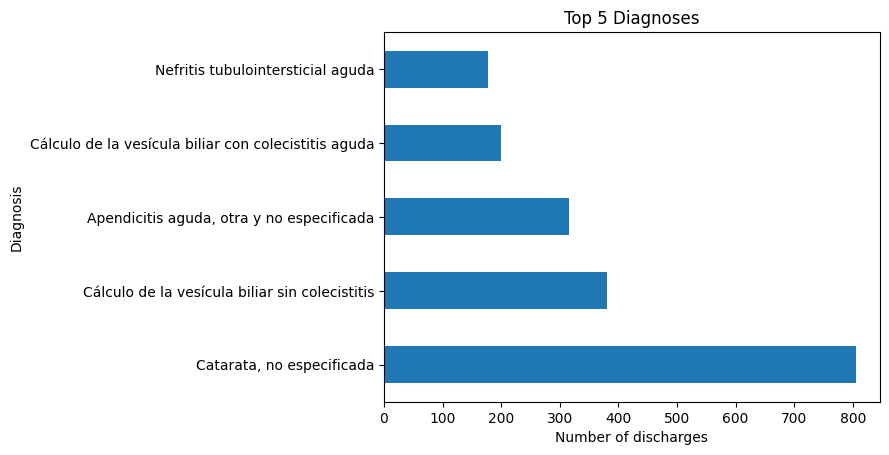

In [49]:
grd_region["Descripción"].value_counts().head(5).plot(kind="barh")
plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")
plt.title("Top 5 Diagnoses")
plt.show()